# Projektarbeit / Aufgabe 4: Analyse der Taschengeldverteilung
## DHBW Ravensburg · Grundlagen Data Science

| Bearbeiter         | Kurs  |
|--------------------|-------|
| Julian Stengele    | TIK24 |
| Johann Flögel      | TIK24 |
| Atussa Mehrawari   | TIK24 |

In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

df = pd.read_csv('docs/DatSci_PKA_4.csv', header=None, names=['Taschengeld'])
# Erste 10 Zeilen anzeigen und Anzahl der Datensätze
print(df.head(10))
print(f"\nAnzahl der Datensätze: {len(df)}")


   Taschengeld
0       491.99
1       448.63
2       508.39
3       509.30
4       379.26
5       362.56
6       482.86
7       500.42
8       529.59
9       523.97

Anzahl der Datensätze: 10000


## Aufgabe 1: Deskriptive Statistiken
Berechnung von Mittelwert, Standardabweichung, Skewness und Kurtosis der Taschengeldverteilung

In [2]:
taschengeld = df.iloc[:, 0]

print("=== AUFGABE 1: DESKRIPTIVE STATISTIKEN ===\n")

# Berechnung der deskriptiven Statistiken
mittelwert = taschengeld.mean()
standardabweichung = taschengeld.std(ddof=1)
skewness = stats.skew(taschengeld.dropna())
kurtosis = stats.kurtosis(taschengeld.dropna(), fisher=True)

print(f"Mittelwert:             {mittelwert:.2f}")
print(f"Standardabweichung:     {standardabweichung:.2f}")
print(f"Skewness:               {skewness:.4f}")
print(f"Kurtosis:               {kurtosis:.4f}")

=== AUFGABE 1: DESKRIPTIVE STATISTIKEN ===

Mittelwert:             492.97
Standardabweichung:     33.64
Skewness:               -1.7100
Kurtosis:               4.8909


## Aufgabe 2: Symmetrie und Schiefe der Verteilung
Überprüfung, ob die Verteilung symmetrisch oder schief ist und ggf. links- oder rechtsschief

=== AUFGABE 2: SYMMETRIE UND SCHIEFE ===

Skewness-Wert: -1.7100
Mittelwert:    492.97
Median:        500.72

Ergebnis: Die Verteilung ist LINKSSCHIEF.
  → Der linke Schwanz ist länger.
  → Mittelwert (492.97) < Median (500.72)


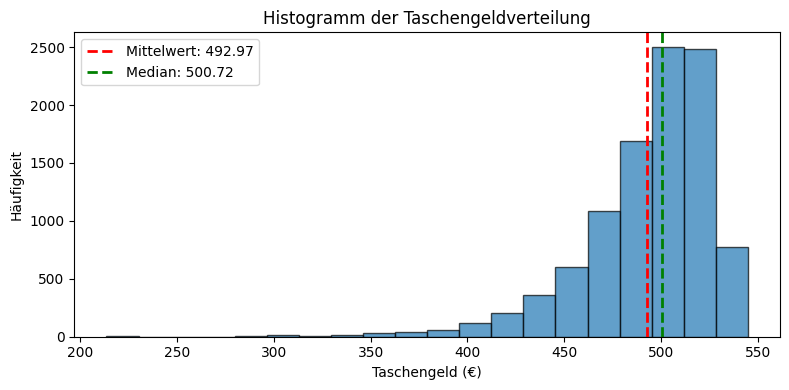

In [3]:
print("=== AUFGABE 2: SYMMETRIE UND SCHIEFE ===\n")

# Median-Berechnung
median = taschengeld.median()

print(f"Skewness-Wert: {skewness:.4f}")
print(f"Mittelwert:    {mittelwert:.2f}")
print(f"Median:        {median:.2f}\n")

# Logik zur Bestimmung der Verteilung
if abs(skewness) < 0.5:
    print("Ergebnis: Die Verteilung ist annähernd SYMMETRISCH.")
elif skewness > 0.5:
    print("Ergebnis: Die Verteilung ist RECHTSSCHIEF.")
    print("  → Der rechte Schwanz ist länger.")
    print(f"  → Mittelwert ({mittelwert:.2f}) > Median ({median:.2f})")
else:
    print("Ergebnis: Die Verteilung ist LINKSSCHIEF.")
    print("  → Der linke Schwanz ist länger.")
    print(f"  → Mittelwert ({mittelwert:.2f}) < Median ({median:.2f})")

# Visualisierung mit Histogramm und vertikalen Linien für Mittelwert und Median
plt.figure(figsize=(8, 4))
plt.hist(taschengeld, bins=20, edgecolor='black', alpha=0.7)
plt.axvline(mittelwert, color='red', linestyle='--', linewidth=2, label=f'Mittelwert: {mittelwert:.2f}')
plt.axvline(median, color='green', linestyle='--', linewidth=2, label=f'Median: {median:.2f}')
plt.xlabel('Taschengeld (€)')
plt.ylabel('Häufigkeit')
plt.title('Histogramm der Taschengeldverteilung')
plt.legend()
plt.tight_layout()
plt.show()


## Aufgabe 3: Mögliche Gründe für die beobachtete Verteilung
Analyse von potentiellen Ursachen der Taschengeldverteilung

Mögliche Ursachen für die beobachtete Taschengeldverteilung:

1. **Institutionelle Obergrenze des Internats**
Da es sich um eine Internatsschule handelt, ist es naheliegend, dass das Internat eine maximale Taschengeldhöhe vorschreibt oder empfiehlt. Im Histogramm ist erkennbar, dass die Werte bei ca. 550 € enden und sich dort stark häufen. Eine solche Obergrenze führt dazu, dass viele Schüler Beträge nahe diesem Maximum erhalten, während einzelne Schüler deutlich weniger bekommen, was die Linksschiefe erklärt.

2. **Unterschiedliche finanzielle Situationen der Familien**
Da es sich um eine Internatsschule handelt, stammen die meisten Schüler (wahrscheinlich) aus wohlhabenderen Familien, was die Häufung im oberen Wertebereich erklärt. Die wenigen Ausreißer nach unten, die im Histogramm bei Werten um 200 bis 300 € sichtbar sind, deuten auf einzelne Schüler mit deutlich geringerem Taschengeld hin und erzeugen so den langen linken Schwanz.

3. **Altersabhängige Unterschiede in der Oberstufe**
Ältere Schüler erhalten tendenziell mehr Taschengeld als jüngere. Da alle Befragten zur Oberstufe gehören, ist der Altersunterschied begrenzt, erklärt aber die moderate Streuung im mittleren und unteren Bereich der Verteilung.

## Aufgabe 4: Prüfung auf Normalverteilung
Untersuchung, ob die Taschengeldverteilung einer Normalverteilung entspricht, sowie Identifikation möglicher Abweichungen und alternativer Verteilungen.

=== AUFGABE 4: NORMALVERTEILUNGSTEST ===

Normaltest Statistik: 3539.6626
p-Wert:               0.0000e+00

Ergebnis: Die Nullhypothese wird abgelehnt. Die Daten sind NICHT normalverteilt.


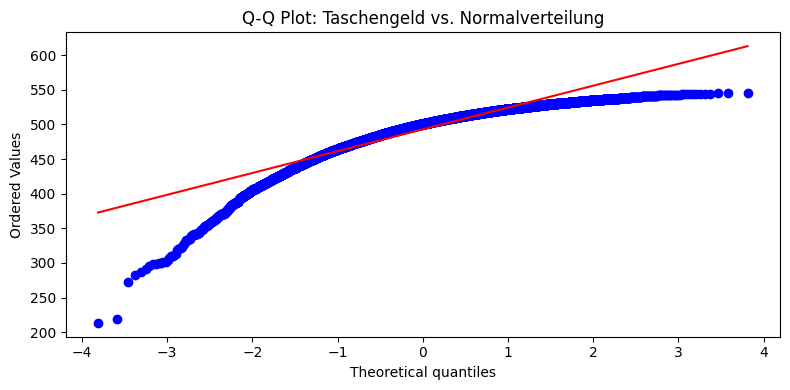

In [4]:
print("=== AUFGABE 4: NORMALVERTEILUNGSTEST ===\n")

# 1. Statistischer Test (D'Agostino's K-squared test)
stat, p_value = stats.normaltest(taschengeld.dropna())
print(f"Normaltest Statistik: {stat:.4f}")
print(f"p-Wert:               {p_value:.4e}\n")

alpha = 0.05
if p_value < alpha:
    print("Ergebnis: Die Nullhypothese wird abgelehnt. Die Daten sind NICHT normalverteilt.")
else:
    print("Ergebnis: Die Nullhypothese kann nicht abgelehnt werden. Die Daten könnten normalverteilt sein.")

# 2. Visuelle Überprüfung (Q-Q Plot)
plt.figure(figsize=(8, 4))
stats.probplot(taschengeld.dropna(), dist="norm", plot=plt)
plt.title('Q-Q Plot: Taschengeld vs. Normalverteilung')
plt.tight_layout()
plt.show()

**Erkenntnisse zur Normalverteilung:**
* **Statistisch:** Der p-Wert ist extrem klein (deutlich unter 0.05), was bestätigt, dass **keine** Normalverteilung vorliegt.
* **Visuell (Q-Q Plot):** Die Datenpunkte weichen an den Rändern stark von der roten theoretischen Linie ab. Besonders im unteren Bereich (linker Schwanz) zeigt sich die bereits in Aufgabe 2 festgestellte Linksschiefe.
* **Welche Verteilung liegt vor?** Da die Daten stark linksschief sind, handelt es sich höchstwahrscheinlich um eine **Schiefnormalverteilung (Skew-Normal Distribution)** oder eventuell um eine (gespiegelte) **Weibull-Verteilung**.

Im Q-Q Plot zeigen sich zwei charakteristische Abweichungen: Im linken Randbereich (theoretische Quantile < −3) liegen die Datenpunkte deutlich unterhalb der Referenzlinie, was auf extreme Ausreißer nach unten und den langen linken Schwanz hindeutet. Im rechten Randbereich (theoretische Quantile > 2) flachen die Punkte ab und bleiben unter der Linie, die Daten enden bei ca. 545 €, was auf eine mögliche Obergrenze (z.B. institutionelle Regelung des Internats) hindeutet.

## Aufgabe 5: Quantitatives Modell
Modellierung der Taschengeldverteilung durch Anpassung einer Schiefnormalverteilung (Skew-Normal Distribution) an die vorliegenden Daten.

=== AUFGABE 5: QUANTITATIVES MODELL ===

Gefundene Parameter für das Modell (Skew-Normal):
Schiefe-Parameter (a): -8.8476
Lageparameter (loc):   532.93
Skalierung (scale):    52.23



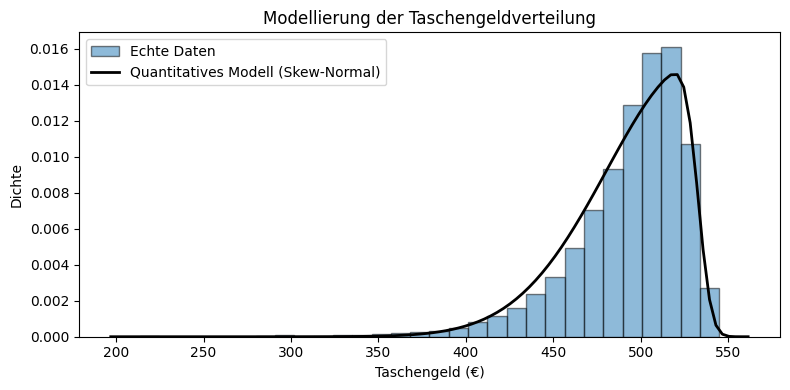

In [5]:
print("=== AUFGABE 5: QUANTITATIVES MODELL ===\n")

# Anpassen der Schiefnormalverteilung (Skew-Normal) an die Daten
# 'fit' liefert die Parameter: Skewness-Faktor (a), Mittelwert (loc) und Standardabweichung (scale)
ae, loce, scalee = stats.skewnorm.fit(taschengeld.dropna())

print("Gefundene Parameter für das Modell (Skew-Normal):")
print(f"Schiefe-Parameter (a): {ae:.4f}")
print(f"Lageparameter (loc):   {loce:.2f}")
print(f"Skalierung (scale):    {scalee:.2f}\n")

# Visualisierung: Histogramm der Daten + gefittete Modellkurve
plt.figure(figsize=(8, 4))

# Originaldaten
plt.hist(taschengeld, bins=30, density=True, edgecolor='black', alpha=0.5, label='Echte Daten')

# X-Werte für die Modellkurve generieren
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)

# Y-Werte der Modellkurve berechnen (Probability Density Function)
p = stats.skewnorm.pdf(x, ae, loce, scalee)

# Modell plotten
plt.plot(x, p, 'k', linewidth=2, label='Quantitatives Modell (Skew-Normal)')

plt.xlabel('Taschengeld (€)')
plt.ylabel('Dichte')
plt.title('Modellierung der Taschengeldverteilung')
plt.legend()
plt.tight_layout()
plt.show()

**Fazit zum Modell:**
Das quantitative Modell (die schwarze Kurve) repräsentiert die asymmetrische, linksschiefe Form der tatsächlichen Taschengeldverteilung deutlich besser als eine klassische Normalverteilung. Mit den berechneten Parametern (a, loc, scale) lässt sich die Verteilung nun mathematisch beschreiben.
Die gefundenen Parameter lassen sich dabei wie folgt interpretieren: Der Schiefe-Parameter a=−8.8476 bestätigt die bereits in Aufgabe 2 festgestellte ausgeprägte Linksschiefe. Je weiter a von 0 entfernt ist, desto stärker ist die Asymmetrie. Bei a=0 würde eine symmetrische Normalverteilung vorliegen. Das negative Vorzeichen gibt an, dass die Verteilung nach links verzerrt ist, d.h. der linke Schwanz ist deutlich länger als der rechte. Der Lageparameter loc=532.93 liegt oberhalb des empirischen Mittelwerts (492.97) und des Medians (500.72), was typisch für linksschiefe Verteilungen ist (Modus > Median > Mittelwert). Inhaltlich bedeutet das, dass die häufigsten Taschengeldzahlungen im oberen Bereich der Verteilung liegen. Der Skalierungsparameter scale=52.23 beschreibt die Streubreite der zugrundeliegenden Verteilung. In Kombination mit der empirischen Standardabweichung von 33.64 € aus Aufgabe 1 zeigt sich, dass die tatsächliche Streuung durch die Schiefe nach unten komprimiert wird.